#### DTS114TC
#### AI-powered System for Meta-software Development
#### Xinyao.Li 2471742


AI generated –Personas (as in the Agile methodology)

In [1]:
import os
import sys

# Add parent directory to path so we can import utils
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

# --- Disable system proxy to avoid ProxyError when connecting to api.apifree.ai ---
for var in ['HTTP_PROXY', 'HTTPS_PROXY', 'http_proxy', 'https_proxy', 'ALL_PROXY', 'all_proxy']:
    os.environ.pop(var, None)
os.environ['NO_PROXY'] = '*'

# Check if Pillow is installed
try:
    from PIL import Image
    print("✅ Pillow already installed")
except:
    print("Installing Pillow...")
    %pip install pillow

# Import helper functions
from utils import load_environment, get_completion

# Load API keys from .env
load_environment()

# Set up the LLM client
client = None
model_name = None
api_provider = None

try:
    from utils import setup_llm_client,clean_llm_output ,get_completion
    client, model_name, api_provider = setup_llm_client("openai/gpt-5.2")
    print(f"✅ LLM Client initialized: {api_provider} - {model_name}")
except Exception as e:
    print(f"❌ Error: {e}")

✅ Pillow already installed
✅ LLM Client configured: Using 'apifree' with model 'openai/gpt-5.2'
✅ LLM Client initialized: apifree - openai/gpt-5.2


Define the business_problem

In [3]:
business_problem = "Our company needs a website that generates a custom horror story and a matching image based on a location entered by the user."

#### 1) AI generated –Business problem

In [3]:
# Check if everything is ready
if client is not None and 'business_problem' in globals():
    print("Generating problem statement...")
    
    prompt = (
        "Given the business problem below, generate one clear and concise problem statement.\n"
        f"Business Problem: {business_problem}"
    )
    
    problem_statement = get_completion(
        prompt, client, model_name, api_provider, temperature=0.3
    )
    print(problem_statement)
else:
    print("Skipping - client or business problem not found.")

Generating problem statement...
Create a website where users enter a location and receive a custom-generated horror story along with a matching image.


#### 2) AI generated –Personas

In [4]:
if client and 'problem_statement' in globals():
    print("--- Generating Personas ---")
    prompt = (
        "Based on the problem statement, generate exactly 3 user personas.\n"
        "For each persona, use this exact format:\n\n"
        "### Persona [N]: [Role Title]\n"
        "- **Responsibilities:** [1-2 sentences]\n"
        "- **Needs:** [1-2 specific needs related to the solution]\n\n"
        "Rules:\n"
        "- Role titles must be single words or short phrases (e.g. 'Casual User', 'Content Creator'), no slashes.\n"
        "- Responsibilities and Needs must be concrete, not abstract. Mention actual actions or features.\n"
        "- Do not add any extra text before or after the personas.\n\n"
        f"Problem Statement: {problem_statement}"
    )
    personas = get_completion(
        prompt, client, model_name, api_provider, temperature=0.2
    )
    print(f"Personas: {personas}")
else:
    print("Skipping step because LLM client or problem statement is not available.")

--- Generating Personas ---
Personas: ### Persona 1: Casual Reader
- **Responsibilities:** Enters a city or address and submits it to generate a horror story. Reads the story on the page and saves or shares it.
- **Needs:** A simple location input with auto-suggestions and a clear “Generate” button; a one-click way to download or share the story and image.

### Persona 2: Travel Blogger
- **Responsibilities:** Generates location-based horror stories for destinations and uses them as content for posts. Downloads images and embeds the story text into articles.
- **Needs:** Options to set story length and tone (e.g., “short,” “local folklore,” “modern”); high-resolution image downloads plus easy copy-to-clipboard for the story.

### Persona 3: Moderator
- **Responsibilities:** Reviews generated stories and images for policy violations and removes flagged content. Responds to user reports and manages blocked locations or prompts.
- **Needs:** An admin dashboard to view generation logs and 

#### 3) AI generated –Requirements based on the problem statement and personas

In [5]:
if client is not None and 'problem_statement' in globals() and 'personas' in globals():
    print("Generating PRD...")
    
    prompt = (
        "Write a Product Requirements Document (PRD) in markdown using only the headings listed below. "
        "Each heading must contain exactly 2-4 bullet points. "
        "Each bullet point must be one sentence and describe a specific, concrete detail. "
        "Do not write vague bullets like 'Build a good UI' — mention actual features or constraints.\n\n"
        "Start directly with '## Overview' — no introductory sentence. "
        "Do not add any headings beyond those listed. Do not write a conclusion.\n\n"
        "## Overview\n## Goals\n## Non-Goals\n## User Personas (brief)\n"
        "## Key Features\n## User Flows\n## Functional Requirements\n"
        "## Non-Functional Requirements\n## Constraints/Assumptions\n"
        "## Success Metrics\n## Open Questions\n\n"
        f"Problem Statement: {problem_statement}\n"
        f"Personas: {personas}"
    )
    
    prd = get_completion(
        prompt, client, model_name, api_provider, temperature=0.3
    )
    prd = clean_llm_output(prd, language='markdown')
    print(prd)
    
    os.makedirs('artifacts', exist_ok=True)
    with open('artifacts/prd.md', 'w') as f:
        f.write(prd)
    print('✅Saved: artifacts/prd.md')
else:
    print("Skipping - client, problem_statement or personas missing.")

Generating PRD...
## Overview
- The website lets users enter a city, address, or landmark and generates a custom horror story tied to that location plus a matching AI image.  
- The results page displays the story text and image together with actions to copy, download, and share.  
- An admin dashboard allows moderators to review generation logs, handle user reports, and remove or block problematic content.  

## Goals
- Provide a fast location-to-story experience with autosuggest location input and a single “Generate” action.  
- Support creator workflows with selectable story length and tone and high-resolution image downloads.  
- Reduce unsafe outputs by applying moderation filters, user reporting, and moderator tools for takedown and blocking.  

## Non-Goals
- The product will not provide real-time navigation, maps, or routing beyond validating and normalizing the entered location string.  
- The product will not guarantee factual historical accuracy about a location and will lab

#### 4) AI generated –User stories from the PRD and personas

In [6]:
if client and 'prd' in globals():
    print("--- Generating User Stories ---")
    prompt = (
        "Return a single JSON object and nothing else — no backticks, no markdown, no introductory text.\n"
        "The JSON must match this schema exactly:\n"
        "{\n  \"user_stories\": [\n    {\n      \"id\": 1,\n"
        "      \"role\": \"<role>\",\n      \"goal\": \"<goal>\",\n"
        "      \"benefit\": \"<benefit>\",\n"
        "      \"acceptance_criteria\": [\"<criteria>\", \"<criteria>\"]\n    }\n  ]\n}\n\n"
        "Rules:\n"
        "- Generate exactly 5 stories.\n"
        "- Each story must have exactly 2 acceptance criteria.\n"
        "- 'role', 'goal', and 'benefit' must each be no more than 20 words.\n"
        "- Each acceptance criterion must be a specific, testable action.\n"
        "- Do not add extra keys or comments.\n\n"
        f"PRD: {prd}"
    )
    user_stories = get_completion(
        prompt, client, model_name, api_provider, temperature=0.3
    )
    user_stories = clean_llm_output(user_stories, language='json')
    print(f"User Stories: {user_stories}")
    # Save user stories as JSON — parse first to avoid double-wrapping
    import json, os
    os.makedirs('artifacts', exist_ok=True)
    parsed = json.loads(user_stories)
    with open('artifacts/user_stories.json', 'w') as f:
        json.dump(parsed, f, indent=2)
    print('✅ Saved: artifacts/user_stories.json')
else:
    print("Skipping step because LLM client or PRD is not available.")

--- Generating User Stories ---
User Stories: {
  "user_stories": [
    {
      "id": 1,
      "role": "Casual Reader",
      "goal": "Enter a location with autosuggest and generate a horror story with an image in one click.",
      "benefit": "I quickly get a location-themed story and matching visual without friction.",
      "acceptance_criteria": [
        "When I type 3+ characters, the location field shows up to 5 geocoding suggestions.",
        "When I select a suggestion and click Generate, the system returns story text, image URL, and generation ID."
      ]
    },
    {
      "id": 2,
      "role": "Travel Blogger",
      "goal": "Choose story length and tone presets before generating the story and image.",
      "benefit": "I can produce content that fits my audience and publishing format.",
      "acceptance_criteria": [
        "When I select a length preset and tone preset, the generation request includes the chosen length and tone values.",
        "When generation compl

## Phase 2: Construction
#### 1) AI generated –UML diagrams

--- Generating PlantUML Use Case Diagram ---
Generated PlantUML diagram:
@startuml
actor "Casual Reader" as CasualReader
actor "Travel Blogger" as TravelBlogger
actor "User" as User
actor "Moderator" as Moderator

rectangle "Horror Story Generator" {
  usecase "Generate story and image" as UC1
  usecase "Set length and tone" as UC2
  usecase "Copy and share results" as UC3
  usecase "Report unsafe content" as UC4
  usecase "Moderate generated content" as UC5
}

CasualReader -- UC1
TravelBlogger -- UC2
CasualReader -- UC3
User -- UC4
Moderator -- UC5
@enduml
✅ Saved: artifacts/diagrams/use_case_diagram.puml
✅ Diagram rendered and saved to: artifacts\diagrams\use_case_diagram.png


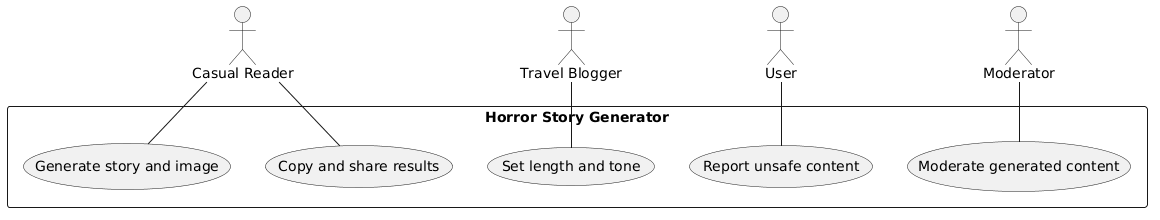

In [7]:
from utils import render_plantuml_diagram

if client and 'user_stories' in globals():
    print("--- Generating PlantUML Use Case Diagram ---")
    
    # 保证 user_stories 是字符串，避免 Python 对象直接拼接到 prompt 里
    stories_text = user_stories
    if isinstance(stories_text, (dict, list)):
        import json
        stories_text = json.dumps(stories_text, indent=2)
    
    prompt = (
        "Generate a UML-compliant PlantUML use case diagram based on the user stories below.\n"
        "Use standard UML notation and PlantUML syntax.\n\n"
        "Required structure (placeholders like ActorName MUST be replaced with real names):\n"
        "@startuml\n"
        "actor RealActorName\n"
        "actor AnotherRealActorName\n\n"
        "rectangle \"System\" {\n"
        "  usecase \"Real Use Case Name\" as UC1\n"
        "  usecase \"Another Real Use Case\" as UC2\n"
        "}\n\n"
        "RealActorName -- UC1\n"
        "AnotherRealActorName -- UC2\n"
        "@enduml\n\n"
        "UML Rules:\n"
        "- Actors must be defined using the `actor` keyword and placed outside the system boundary\n"
        "- The system boundary must be a `rectangle` with a meaningful system name (default: \"System\")\n"
        "- Use cases must be defined using the `usecase` keyword and placed inside the system boundary\n"
        "- Associations between actors and use cases must use `--` (undirected association), not arrows\n"
        "- Do NOT number use case names; use clear verb–noun phrases instead\n"
        "- Extract unique actors from the `role` field in the user stories; replace all placeholder names with these actors\n"
        "- Create one use case per distinct `goal` field; replace placeholder use case names with these goals\n"
        "- Keep use case names concise (max 5 words)\n"
        "- Only use `<<include>>` or `<<extend>>` if the user stories explicitly and unambiguously require reuse or conditional behavior. If there is any doubt, default to simple `--` associations.\n"
        "- Do NOT use any layout directives (e.g., `left to right direction`, `skinparam`). The diagram should follow default PlantUML layout.\n"
        "- Return ONLY valid PlantUML code, with no explanations or commentary\n\n"
        f"User Stories: {stories_text}"
    )

    puml = get_completion(
        prompt, client, model_name, api_provider, temperature=0.3
    )
    puml = clean_llm_output(puml, language='text')
    print("Generated PlantUML diagram:")
    print(puml)
    
    if not puml.strip().startswith('@startuml') or '@enduml' not in puml:
        print("⚠️  Warning: generated PlantUML may be missing @startuml or @enduml, rendering might fail.")
    
    # Save PUML file
    os.makedirs('artifacts/diagrams', exist_ok=True)
    with open('artifacts/diagrams/use_case_diagram.puml', 'w') as f:
        f.write(puml)
    print('✅ Saved: artifacts/diagrams/use_case_diagram.puml')
    # Pass path WITHOUT "artifacts/" prefix — render_plantuml_diagram resolves it under artifacts/ automatically
    render_plantuml_diagram(puml, "diagrams/use_case_diagram.png")
else:
    print("Skipping step because LLM client or user_stories is not available.")

#### 2a) AI generated – Backend API (Flask main.py)

In [21]:
# Copy utils.py and .env to Flask app directory so main.py can use image generation
import shutil, os

os.makedirs('artifacts/app/flask', exist_ok=True)

# Copy utils.py (same directory as notebook)
src_utils = 'utils.py'
dst_utils = 'artifacts/app/flask/utils.py'
if os.path.exists(src_utils):
    shutil.copy2(src_utils, dst_utils)
    print(f'✅ Copied utils.py to artifacts/app/flask/')
else:
    print(f'⚠️ utils.py not found at {src_utils}')

# Copy .env (same directory as notebook)
src_env = '.env'
dst_env = 'artifacts/app/flask/.env'
if os.path.exists(src_env):
    shutil.copy2(src_env, dst_env)
    print(f'✅ Copied .env to artifacts/app/flask/')
else:
    print(f'⚠️ .env not found at {src_env}')

✅ Copied utils.py to artifacts/app/flask/
✅ Copied .env to artifacts/app/flask/


In [22]:
if client and 'user_stories' in globals():
    import json, re, os
    print("--- Phase 2.2a: Generating Flask API (main.py) ---")
    
    # Parse user stories
    try:
        stories_data = json.loads(user_stories) if isinstance(user_stories, str) else user_stories
        stories_list = stories_data if isinstance(stories_data, list) else stories_data.get('user_stories', [])
    except:
        print("Error parsing user stories")
        stories_list = []
    
    # Build all 5 stories as a single text block for the prompt
    stories_text = ""
    for i, story in enumerate(stories_list[:5], 1):
        stories_text += f"Story {i}: Role={story.get('role','')}, Goal={story.get('goal','')}, Benefit={story.get('benefit','')}\n"
    
    # Generate ALL endpoints in ONE API call so routes are consistent
    print("  Generating all 5 endpoints in one batch...")
    
    all_endpoints = get_completion(
        f"Write Flask endpoint functions for ALL 5 user stories below. Use stories_db list for storage.\n\n"
        f"User Stories:\n{stories_text}\n\n"
        f"Rules:\n"
        f"- Write complete @app.route decorated functions for EVERY story (1-2 per story).\n"
        f"- Every function MUST have a UNIQUE name (do NOT reuse function names).\n"
        f"- Routes must be consistent: use a common prefix like /api/ for data endpoints, /mod/ for moderator endpoints.\n"
        f"- Return ONLY the function code (decorated functions), no imports, no app initialization, no app.run().\n"
        f"- Endpoints must return JSON with proper status codes.\n"
        f"- CRITICAL — JSON field names: the story text MUST be returned under the key 'story'. The image URL MUST be under the key 'image_url'.\n"
        f"- CRITICAL — You MUST include a GET /api/stories endpoint that returns ALL stored stories as a JSON array (the frontend history feature depends on it).\n"
        f"- For story content: use hardcoded placeholder horror stories (2-4 sentences each).\n"
        f"- For image_url: call get_image_generation_completion() to generate a REAL AI horror image.\n"
        f"  Use: file_path, image_url = get_image_generation_completion(\n"
        f"      f'A dark, eerie, cinematic horror scene at {{location}}: haunted, foggy, unsettling atmosphere',\n"
        f"      None, 'qwen/qwen-image-2512', 'apifree')\n"
        f"  If image_url is None or the call fails, fall back to: f'https://picsum.photos/seed/{{int(time.time())}}/1024/768'\n"
        f"  The image prompt MUST be descriptive and scary, matching the location and story tone.\n"
        f"- Never reference undefined functions like generate_text() or globals().get().\n"
        f"- Assume 'import time' and 'from utils import get_image_generation_completion' already exist at the top of the file.\n"
        f"- Add a comment before each story's endpoints, e.g. '# Story 1: Casual Reader'.",
        client, model_name, api_provider, temperature=0.3
    )
    all_endpoints = clean_llm_output(all_endpoints, language='python')
    
    print(f"✅ Generated endpoints for all 5 stories")
    
    # Generate base app structure
    base_app = get_completion(
        "Create a minimal Flask app skeleton with exactly these lines:\n"
        "from flask import Flask, request, jsonify, send_from_directory\n"
        "from flask_cors import CORS\n"
        "import time\n"
        "app = Flask(__name__)\n"
        "CORS(app)\n"
        "stories_db = []\n"
        "@app.get('/health')\n"
        "def health():\n"
        "    return jsonify(status='ok')\n"
        "Do NOT include if __name__ == '__main__' or app.run(). Return ONLY the Python code, no markdown fences.",
        client, model_name, api_provider, temperature=0.1
    )
    base_app = clean_llm_output(base_app, language='python')
    
    # Ensure import time is present
    if 'import time' not in base_app:
        base_app = 'import time\n' + base_app
    
    # Strip any accidental app.run() or if __name__ block
    clean_lines = []
    for line in base_app.split('\n'):
        stripped = line.strip()
        if 'if __name__' in stripped or 'app.run(' in stripped:
            continue
        clean_lines.append(line)
    base_app = '\n'.join(clean_lines)
    
    # Setup code for real AI image generation via utils.py
    setup_code = (
        "import sys, os\n"
        "try:\n"
        "    from dotenv import load_dotenv\n"
        "    load_dotenv()\n"
        "except ImportError:\n"
        "    pass\n"
        "sys.path.insert(0, os.path.dirname(os.path.abspath(__file__)))\n"
        "from utils import get_image_generation_completion\n"
    )
    
    # Add frontend serving routes
    frontend_route = """
# Serve frontend
@app.route('/')
def index():
    return send_from_directory('.', 'index.html')

@app.route('/<path:filename>')
def serve_static(filename):
    return send_from_directory('.', filename)
"""
    
    # Combine all code
    main_py_code = setup_code + base_app + "\n" + all_endpoints + frontend_route
    main_py_code += "\n\nif __name__ == '__main__':\n    app.run(host='0.0.0.0', debug=True, port=5005)"
    
    os.makedirs('artifacts/app/flask', exist_ok=True)
    with open('artifacts/app/flask/main.py', 'w') as f:
        f.write(main_py_code)
    print('✅ Saved: artifacts/app/flask/main.py')
    
    # Extract routes for use by later cells
    route_pattern = r"@app\.(?:route|get|post|put|delete|patch)\(['\"]([^'\"]+)['\"](?:,\s*methods=\[([^\]]+)\])?\)"
    routes = re.findall(route_pattern, main_py_code)
    routes_text = ', '.join([f"{route} ({methods if methods else 'GET'})" for route, methods in routes])
    print(f"  Available API endpoints: {routes_text}")
else:
    print("Skipping step because LLM client or user_stories is not available.")

--- Phase 2.2a: Generating Flask API (main.py) ---
  Generating all 5 endpoints in one batch...
✅ Generated endpoints for all 5 stories
✅ Saved: artifacts/app/flask/main.py
  Available API endpoints: /health (GET), /api/locations/suggest ("GET"), /api/generate ("POST"), /api/presets ("GET"), /api/generate/custom ("POST"), /api/stories ("GET"), /api/stories/<story_id>/share ("POST"), /api/stories/<story_id>/report ("POST"), /mod/reports ("GET"), /mod/stories/<story_id>/action ("POST"), / (GET), /<path:filename> (GET)


#### 2b) AI generated – Frontend HTML (index.html)

In [19]:
if client and 'routes_text' in globals():
    import os
    print("--- Phase 2.2b: Generating Frontend (index.html) ---")
    
    html_prompt = (
        "Generate a complete, production-ready HTML5 webpage that serves as a frontend for a horror story generator.\n"
        "EXACT API ROUTES YOU MUST USE (no guessing, no inventing new routes):\n"
        "  - Story generation: POST /api/generate with JSON body {location: userInput}. Returns {story, image_url, id, created_at}.\n"
        "  - Story history: GET /api/stories returns JSON array of all stored stories.\n"
        "  - Location suggestions: GET /api/locations/suggest?q=... returns {suggestions: [...]}.\n"
        "  - Health check: GET /health.\n"
        "Requirements:\n"
        "(1) Use Bootstrap 5 CSS framework via CDN for professional styling.\n"
        "(2) Include an input field for the user to type a location and a 'Generate' button.\n"
        "(3) When button is clicked, send POST /api/generate with JSON {location: userInput}.\n"
        "(4) Display the returned story and image (field 'image_url' in img tag).\n"
        "(5) Load history from GET /api/stories and display in cards.\n"
        "(6) Client-side validation (location must not be empty).\n"
        "(7) Loading spinner while generating.\n"
        "(8) User-friendly error messages.\n"
        "(9) All CSS in style tags, all JS in script tags.\n"
        "(10) Use Fetch API with relative URLs.\n"
        "(11) CRITICAL: formatMeta(created_at) MUST use 'new Date(created_at * 1000)' — backend stores Unix seconds.\n"
        "(12) Do NOT include Share, Report, or any moderation buttons. Simple UI only.\n"
        "Output ONLY the complete valid HTML document. No markdown fences. No explanations.\n"
    )
    
    html_code = get_completion(
        html_prompt, client, model_name, api_provider, temperature=0.4
    )
    html_code = clean_llm_output(html_code, language='html')
    
    os.makedirs('artifacts/app/flask', exist_ok=True)
    with open('artifacts/app/flask/index.html', 'w') as f:
        f.write(html_code)
    print('✅ Saved: artifacts/app/flask/index.html')
else:
    print("Skipping step because LLM client or routes_text is not available.")

--- Phase 2.2b: Generating Frontend (index.html) ---
✅ Saved: artifacts/app/flask/index.html


#### 2c) AI generated – Documentation (README.md)

In [24]:
if client and 'routes_text' in globals():
    print("--- Phase 2.2c: Generating README.md ---")
    
    readme_content = get_completion(
        "Write a README.md (under 250 words) for an integrated Flask horror story generator API with HTML frontend. "
        "Include: title, description, setup (pip install flask flask-cors), run command (python main.py), "
        "how to access the app (http://127.0.0.1:5005), and 2 curl examples for the main POST and GET endpoints "
        "(use the actual endpoint routes: " + routes_text + "). "
        "Also mention the interactive HTML frontend is served automatically.",
        client, model_name, api_provider, temperature=0.3
    )
    with open('artifacts/app/flask/README.md', 'w') as f:
        f.write(readme_content)
    print('✅ Saved: artifacts/app/flask/README.md')
else:
    print("Skipping step because LLM client or routes_text is not available.")

--- Phase 2.2c: Generating README.md ---
✅ Saved: artifacts/app/flask/README.md


#### 2d) AI generated – Dependencies (requirements.txt)

In [25]:
if client and os.path.exists('artifacts/app/flask/main.py'):
    print("--- Generating requirements.txt ---")
    
    # 1. Robustly read the app code
    try:
        with open('artifacts/app/flask/main.py', 'r') as f:
            app_code = f.read()
    except Exception as e:
        print(f"❌ Failed to read main.py: {e}")
        raise

    # 2. Enhanced extraction logic: scan all lines for imports
    import_lines = []
    for line in app_code.split('\n'):
        line = line.strip()
        # Capture lines starting with 'import' or 'from'
        if line.startswith('import ') or line.startswith('from '):
            import_lines.append(line)
            
    imports_text = '\n'.join(import_lines)
    print(f"  Found {len(import_lines)} import statement(s)")

    # 3. Prompt AI to generate a standardized list with versions
    prompt = f"""
    Based on the following Python import statements, extract all third-party dependencies:
    {imports_text}

    Requirements:
    1. Output format: One package per line with version specifier using '>=' (e.g., flask>=3.0, flask-cors>=4.0).
    2. Use minimum version requirements only, not exact pins.
    3. Exclude all Python standard libraries.
    4. Output only the package list, no extra text.
    """
    
    requirements = get_completion(prompt, client, model_name, api_provider, temperature=0.1)
    
    # 4. Strict cleaning logic
    req_lines = [line.strip() for line in requirements.split('\n') if line.strip()]
    
    # 5. Add extra dependencies needed by utils.py (image generation)
    extra_deps = ['requests>=2.28', 'Pillow>=10.0', 'python-dotenv>=1.0']
    for dep in extra_deps:
        pkg_name = dep.split('>=')[0]
        if not any(pkg_name.lower() in r.lower() for r in req_lines):
            req_lines.append(dep)
    
    # Remove duplicates and sort
    req_list = sorted(list(set(req_lines)))
    
    # 6. Save to file
    with open('artifacts/app/flask/requirements.txt', 'w') as f:
        f.write('\n'.join(req_list))
    
    print(f'✅ Successfully generated: artifacts/app/flask/requirements.txt')
    print(f"  Dependencies included: {', '.join(req_list)}")

else:
    print("❌ Error: main.py not found. Please ensure the Flask app generation cell has finished.")

--- Generating requirements.txt ---
  Found 6 import statement(s)
✅ Successfully generated: artifacts/app/flask/requirements.txt
  Dependencies included: Pillow>=10.0, flask-cors>=4.0, flask>=3.0, python-dotenv>=1.0, requests>=2.28


#### 2e) AI generated — Static AI-generated banner image
This cell generates a single horror-themed banner image via the AI image generation API and embeds it at the top of the website. This ensures the site always displays at least one AI-generated image on page load, without requiring user interaction.

In [2]:
# Generate a static AI horror banner image and embed it in the frontend
if client and os.path.exists('artifacts/app/flask/index.html'):
    from utils import get_image_generation_completion
    print("--- Generating static AI banner image ---")
    
    prompt = (
        "A dark, eerie cinematic horror banner: haunted mansion silhouette against a blood-red moon, "
        "fog rolling over dead trees, gothic atmosphere, wide panoramic composition, high contrast, terrifying but beautiful"
    )
    
    try:
        _, image_url = get_image_generation_completion(prompt, None, "qwen/qwen-image-2512", "apifree")
    except Exception:
        image_url = None
    
    if image_url:
        with open('artifacts/app/flask/index.html', 'r') as f:
            html = f.read()
        
        banner = f'<div style="max-width:800px;margin:0 auto 1rem;border-radius:8px;overflow:hidden;box-shadow:0 4px 24px rgba(0,0,0,.6)"><img src="{image_url}" alt="AI-generated horror artwork" style="width:100%;display:block"></div>'
        
        import re
        if banner not in html:
            html = re.sub(r'(<body[^>]*>)', r'\1\n' + banner, html, count=1)
            with open('artifacts/app/flask/index.html', 'w') as f:
                f.write(html)
            print('✅ AI-generated banner image embedded in index.html')
        else:
            print('⚠️ Banner already exists, skipped')
    else:
        print('⚠️ Image generation failed, banner not added')
else:
    print("Skipping step — client or index.html not available.")

--- Generating static AI banner image ---
Generating image... This may take a moment.


⏳ Generating image...

Still generating image... (poll 5/60)
✅ Image generated in 35.79 seconds.
✅ Image saved to: artifacts\artifacts\screens\image_1780306523084.png
✅ AI-generated banner image embedded in index.html


In [3]:
# Make story text blood red for better horror aesthetic
if os.path.exists('artifacts/app/flask/index.html'):
    with open('artifacts/app/flask/index.html', 'r') as f:
        html = f.read()
    
    fix_css = '.story-text{color:#cc0000!important}'
    
    if fix_css not in html:
        html = html.replace('</style>', fix_css + '\n</style>')
        with open('artifacts/app/flask/index.html', 'w') as f:
            f.write(html)
        print('✅ Story text changed to blood red')
    else:
        print('⚠️ Already applied')
else:
    print('❌ index.html not found')

✅ Story text changed to blood red


## Phase 3: CI/CD & Deployment
#### AI generated – Docker containerization, CI/CD pipeline, and version control configuration

In [11]:
if client:
    import os
    print("--- Phase 3a: Generating Docker & Git configuration ---")
    
    # Generate Dockerfile
    dockerfile_prompt = (
        "Write a production-ready Dockerfile for a Python Flask application.\n"
        "The first line MUST be 'FROM python:3.11-slim' — no title, no heading, no markdown.\n"
        "Requirements:\n"
        "- FROM python:3.11-slim\n"
        "- WORKDIR /app\n"
        "- Copy requirements.txt and install dependencies with pip\n"
        "- Copy main.py, index.html, and utils.py into /app.\n"
        "- Do NOT copy .env (it contains secrets and is excluded from the repository).\n"
        "- EXPOSE 5005\n"
        "- CMD [\"python\", \"main.py\"]\n"
        "- Use best practices: cache-optimized layer ordering, non-root user\n"
        "Output ONLY the Dockerfile content, starting directly with FROM. No markdown fences."
    )
    
    dockerfile = get_completion(
        dockerfile_prompt, client, model_name, api_provider, temperature=0.2
    )
    dockerfile = clean_llm_output(dockerfile, language='')
    
    # Clean up: strip any leading non-Dockerfile lines
    valid_keywords = ('FROM', 'ENV', 'WORKDIR', 'COPY', 'RUN', 'EXPOSE', 'CMD', 'USER', 'ARG', 'LABEL', 'ADD', 'VOLUME', 'ENTRYPOINT', 'HEALTHCHECK', 'SHELL', 'MAINTAINER', 'STOPSIGNAL', 'ONBUILD')
    lines = dockerfile.strip().split('\n')
    start_idx = 0
    for i, line in enumerate(lines):
        stripped = line.strip()
        if not stripped or stripped.startswith('#'):
            continue
        first_word = stripped.split()[0] if stripped.split() else ''
        if first_word in valid_keywords:
            start_idx = i
            break
    dockerfile = '\n'.join(lines[start_idx:]).strip() + '\n'
    
    os.makedirs('artifacts/app/flask', exist_ok=True)
    with open('artifacts/app/flask/Dockerfile', 'w') as f:
        f.write(dockerfile)
    print('✅ Saved: artifacts/app/flask/Dockerfile')
    
    # Generate .dockerignore
    dockerignore_prompt = (
        "Write a .dockerignore file for a Python Flask project.\n"
        "Exclude: __pycache__, *.pyc, __pycache__ in subdirectories, .git, .gitignore,\n"
        "*.md, venv, .venv, artifacts/screens, .ipynb_checkpoints, *.egg-info, dist, build.\n"
        "Output ONLY the file content, no explanations."
    )
    
    dockerignore = get_completion(
        dockerignore_prompt, client, model_name, api_provider, temperature=0.1
    )
    dockerignore = clean_llm_output(dockerignore, language='')
    
    with open('artifacts/app/flask/.dockerignore', 'w') as f:
        f.write(dockerignore)
    print('✅ Saved: artifacts/app/flask/.dockerignore')
    
    # Generate .gitignore (at repo root)
    gitignore_prompt = (
        "Write a .gitignore file for a Python project with Jupyter notebooks and Flask app.\n"
        "Exclude these patterns (one per line):\n"
        "__pycache__/, *.pyc, venv/, .venv/, .env, .env.*,\n"
        ".ipynb_checkpoints/, *.py[cod], .Python, pip-log.txt, .DS_Store, Thumbs.db,\n"
        "*.egg-info/, dist/, build/, *.log, artifacts/screens/\n"
        "CRITICAL: write '.env' as a standalone pattern WITHOUT trailing slash\n"
        "so it matches BOTH files and directories named .env.\n"
        "Output ONLY the file content, no explanations. No markdown fences. No leading 'gitignore' text."
    )
    
    gitignore = get_completion(
        gitignore_prompt, client, model_name, api_provider, temperature=0.1
    )
    gitignore = clean_llm_output(gitignore, language='')
    
    # Remove any stray first line that isn't a valid gitignore pattern
    lines = gitignore.strip().split('\n')
    clean = []
    for line in lines:
        stripped = line.strip()
        if stripped.lower() in ('gitignore', ''):
            continue
        clean.append(line)
    gitignore = '\n'.join(clean).strip() + '\n'
    
    with open('../.gitignore', 'w') as f:
        f.write(gitignore)
    print('✅ Saved: ../.gitignore')
else:
    print("Skipping step because LLM client is not available.")

--- Phase 3a: Generating Docker & Git configuration ---
✅ Saved: artifacts/app/flask/Dockerfile
✅ Saved: artifacts/app/flask/.dockerignore
✅ Saved: ../.gitignore


In [13]:
if client and os.path.exists('artifacts/app/flask/Dockerfile'):
    import os
    print("--- Phase 3b: Generating GitHub Actions CI/CD workflow ---")
    
    ci_prompt = (
        "Write a GitHub Actions workflow YAML file (.github/workflows/ci.yml) for a Docker-based Python Flask app.\n\n"
        "Requirements:\n"
        "- Trigger: push to main, pull requests to main\n"
        "- Job 1 'lint': checkout code, set up Python 3.11, pip install flake8,\n"
        "  then run flake8 on a single file: flake8 Task1/artifacts/app/flask/main.py\n"
        "  Use flake8 args: --ignore=E302,E401,E402,E501,F401,F403,F405,W292,W503\n"
        "- Job 2 'build-and-push': needs lint, checkout code,\n"
        "  log in to GitHub Container Registry (ghcr.io) with ${{ secrets.GITHUB_TOKEN }},\n"
        "  set up Docker Buildx,\n"
        "  then first run a step: 'Lowercase owner' that converts the repository owner to lowercase\n"
        "  using bash: echo \"OWNER_LC=${OWNER,,}\" >> $GITHUB_ENV with env OWNER=${{ github.repository_owner }}.\n"
        "  Then build Docker image (context: Task1/artifacts/app/flask/),\n"
        "  tag it as ghcr.io/${{ env.OWNER_LC }}/horror-story-generator:latest,\n"
        "  push to ghcr.io.\n"
        "- Use actions/checkout@v4, actions/setup-python@v5, docker/login-action@v3,\n"
        "  docker/setup-buildx-action@v3, docker/build-push-action@v5\n"
        "Output ONLY the valid YAML, no explanations."
    )
    
    ci_yaml = get_completion(
        ci_prompt, client, model_name, api_provider, temperature=0.2
    )
    ci_yaml = clean_llm_output(ci_yaml, language='yaml')
    
    os.makedirs('../.github/workflows', exist_ok=True)
    with open('../.github/workflows/ci.yml', 'w') as f:
        f.write(ci_yaml)
    print('✅ Saved: ../.github/workflows/ci.yml')
else:
    print("Skipping step because LLM client or Dockerfile is not available.")

--- Phase 3b: Generating GitHub Actions CI/CD workflow ---
✅ Saved: ../.github/workflows/ci.yml


#### AI Use Statement
Tool Used: DeepSeek (Large Language Model)
Nature of Assistance:
I have utilized DeepSeek as a collaborative tool to enhance the quality and efficiency of this project in the following ways:

Brainstorming and Logic Design: DeepSeek was used to explore initial concepts for the meta-software architecture and to discuss the logical flow between the Jupyter Notebook and the automatically generated Flask system.

Code Debugging and Optimization: I consulted the AI to identify and resolve specific technical bugs and to improve the efficiency of certain code blocks within the notebook.

Linguistic Refinement: The AI assisted in polishing the Markdown text to ensure professional tone and clarity. It was also used to refine code comments for better readability.

Documentation Support: While the core SDLC requirements and UML structures were designed by me, DeepSeek helped in structuring the descriptive text for the generated documentation.
Statement of Originality:

In accordance with the module's academic integrity policy, I confirm that all final system design choices, the core implementation of the generative mechanisms, and the critical analysis of the software development methodologies are my own work. DeepSeek was used as a "smart assistant" and not as an "author" for the assessment's substantive content.